In [1]:
from torchvision import transforms
classes = ['Angry', 'Fear', 'Happy', 'Sad', 'Surprise']
train_transforms = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ToTensor(),
])
test_transforms = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.ToTensor()
])

In [2]:
from torchvision.datasets import ImageFolder
train_data = ImageFolder('data/faces/train/', train_transforms)
test_data = ImageFolder('data/faces/test/', test_transforms)

In [3]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_data,
                              batch_size=128,
                              shuffle=True,
                              num_workers=10,
                              pin_memory=True)
test_dataloader = DataLoader(test_data,
                             batch_size=64,
                             shuffle=False,
                             num_workers=6,
                             pin_memory=True)

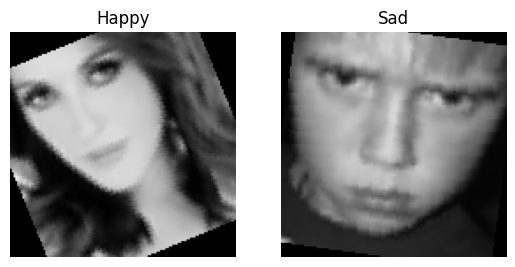

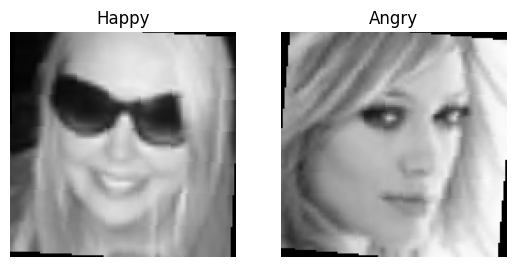

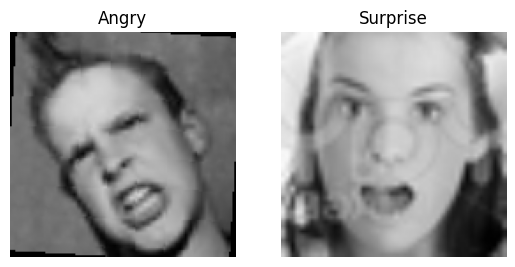

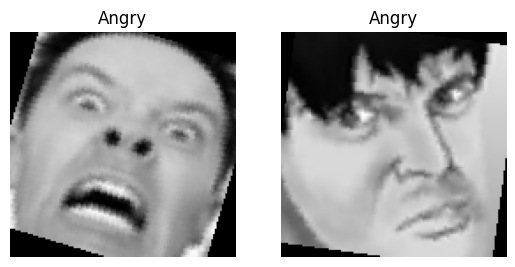

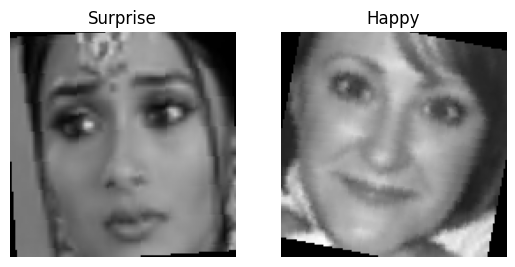

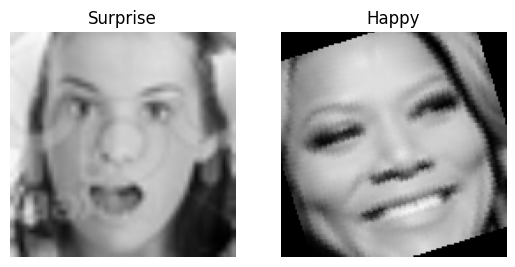

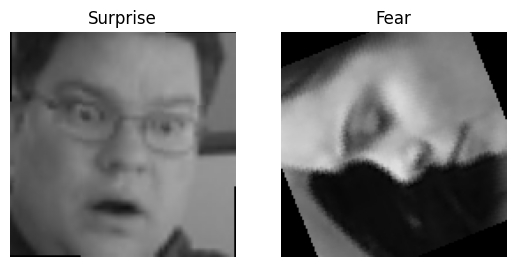

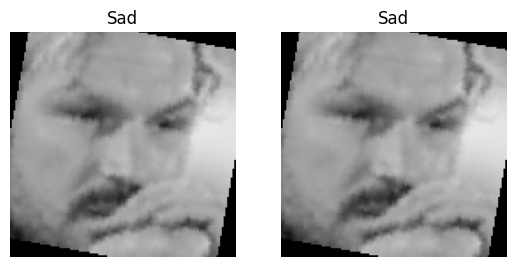

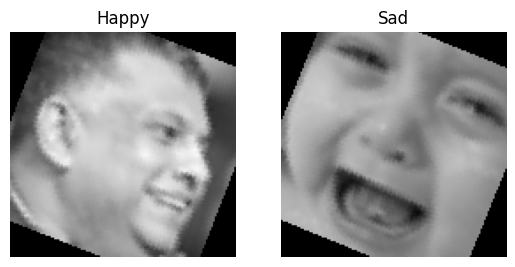

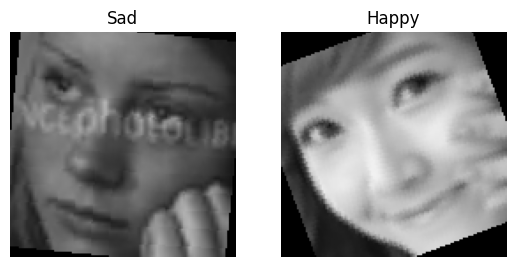

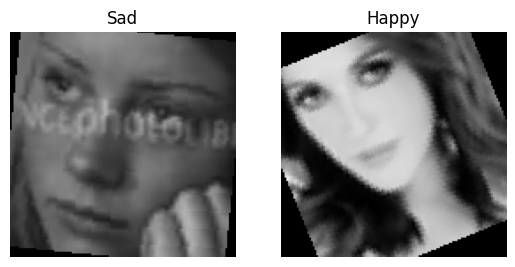

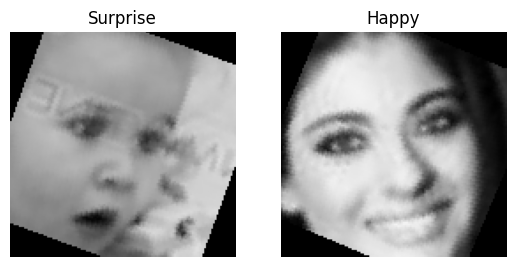

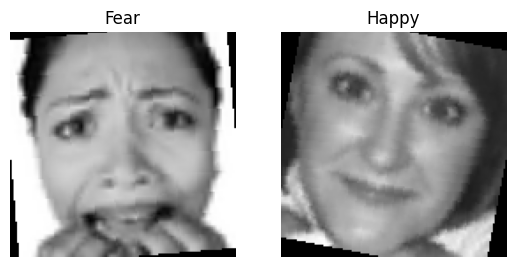

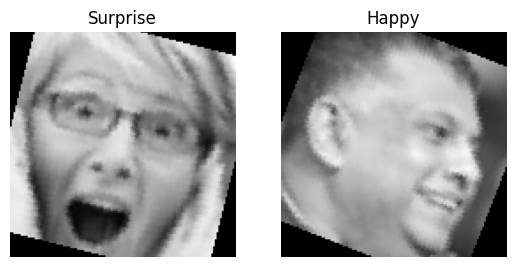

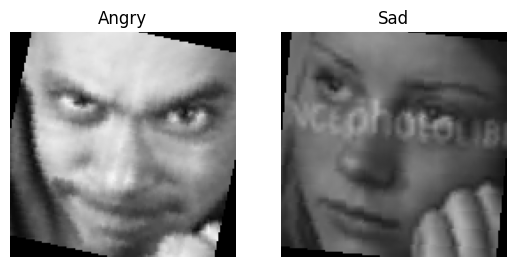

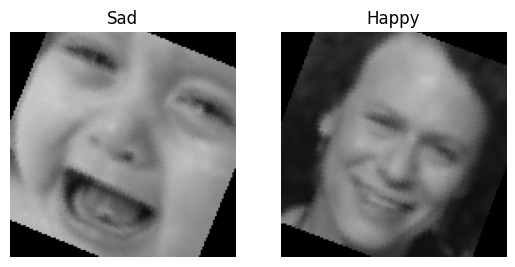

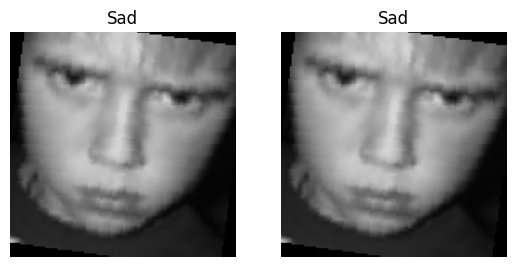

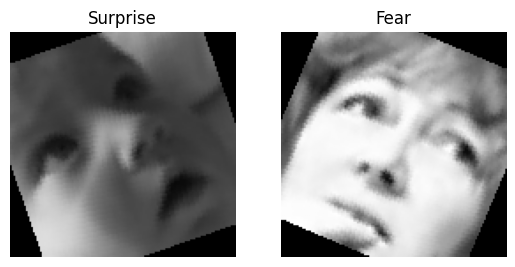

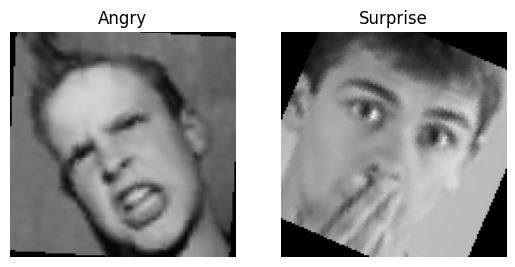

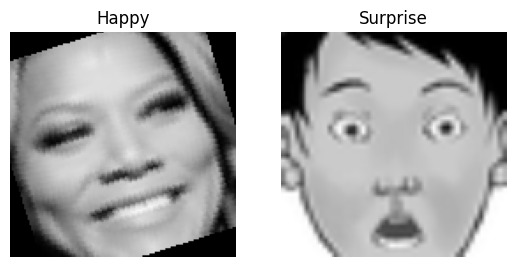

In [4]:
from matplotlib import pyplot as plt
import numpy as np
x, y = next(iter(train_dataloader))
for i in range(20):
    ridx = np.random.randint(0, 64)
    fig, ax = plt.subplots(1, 2)
    img = x[ridx].squeeze().permute(1, 2, 0).numpy()
    ax[0].imshow(img)
    ax[0].axis(False)
    ax[0].set_title(classes[y[ridx].item()])
    ridx = np.random.randint(0, 64)
    img = x[ridx].squeeze().permute(1, 2, 0).numpy()
    ax[1].imshow(img)
    ax[1].axis(False)
    ax[1].set_title(classes[y[ridx].item()])

In [5]:
from torch import nn
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
class basline(nn.Module):
    def __init__(self, out_shape):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, out_shape)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model0 = basline(5).to(device)

In [6]:
from torch import optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model0.parameters(), lr=3e-4, weight_decay=1e-5)
sheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, 175)

In [7]:
# ...existing code...
from torch import optim
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

# create writer once and close after training (not every epoch)
writer = SummaryWriter(log_dir='runs')

epochbatch = len(train_dataloader)


# ...existing code...
def evaluate_model(model, loader, device):
    """Calculates the accuracy of the model on the test/validation set."""
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    accuracy = 100. * correct / total
    return accuracy

def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs, device):
    best_acc = 0.0
    print(f"Starting training on {device}...")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (inputs, targets) in enumerate(train_bar):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # step scheduler per batch if appropriate
            scheduler.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            train_bar.set_postfix({
                'Loss': f'{train_loss/(batch_idx+1):.4f}',
                'Acc': f'{100.*correct/total:.2f}%',
                'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
            })

        # Evaluate on the test set after each epoch
        test_acc = evaluate_model(model, test_loader, device)
        print(f"Test Accuracy after Epoch {epoch+1}: {test_acc:.2f}%")
        writer.add_scalar('Epoch/acc', test_acc, epoch)
        # DO NOT close writer here

        if test_acc > best_acc:
            best_acc = test_acc
            print(f"** New best model saved with accuracy: {best_acc:.2f}% **")
            # save checkpoint if desired

    # close writer after training completes
    writer.close()
    torch.cuda.empty_cache()
    print(f"\nTraining complete. Best Test Accuracy: {best_acc:.2f}%")
# ...existing code...

In [20]:
train_model(model0, train_dataloader, test_dataloader, criterion, optimizer, sheduler, 225, device)

Starting training on cuda...


Epoch 1/225: 100%|██████████| 362/362 [00:15<00:00, 23.91it/s, Loss=1.3508, Acc=43.55%, LR=0.000214]


Test Accuracy after Epoch 1: 45.25%
** New best model saved with accuracy: 45.25% **


Epoch 2/225: 100%|██████████| 362/362 [00:15<00:00, 23.92it/s, Loss=1.2936, Acc=46.38%, LR=0.000183]


Test Accuracy after Epoch 2: 48.95%
** New best model saved with accuracy: 48.95% **


...

Test Accuracy after Epoch 223: 90.32%


Epoch 224/225: 100%|██████████| 362/362 [00:15<00:00, 24.00it/s, Loss=0.1465, Acc=94.79%, LR=0.000219]


Test Accuracy after Epoch 224: 90.45%


Epoch 225/225: 100%|██████████| 362/362 [00:15<00:00, 23.95it/s, Loss=0.1431, Acc=94.82%, LR=0.000246]


Test Accuracy after Epoch 225: 89.93%

Training complete. Best Test Accuracy: 90.56%


In [9]:
# Function to make a prediction on a single image
def predict_single_image(model, image_tensor, device):
    # 1. Ensure the model is in evaluation mode
    model.eval()
    
    # 2. Add a batch dimension and move to the device (GPU)
    # The model expects [Batch, Channel, Height, Width]. 
    # Our image_tensor is currently [1, 28, 28]. We need to add the batch dim.
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    # 3. Disable gradient tracking
    with torch.no_grad():
        # 4. Forward Pass: Get the logits
        output_logits = model(input_tensor)
    
    # 5. Convert logits to class index
    # argmax(dim=1) gets the highest score's index, which is the predicted digit
    predicted_class = output_logits.argmax(dim=1).item()
    
    return predicted_class

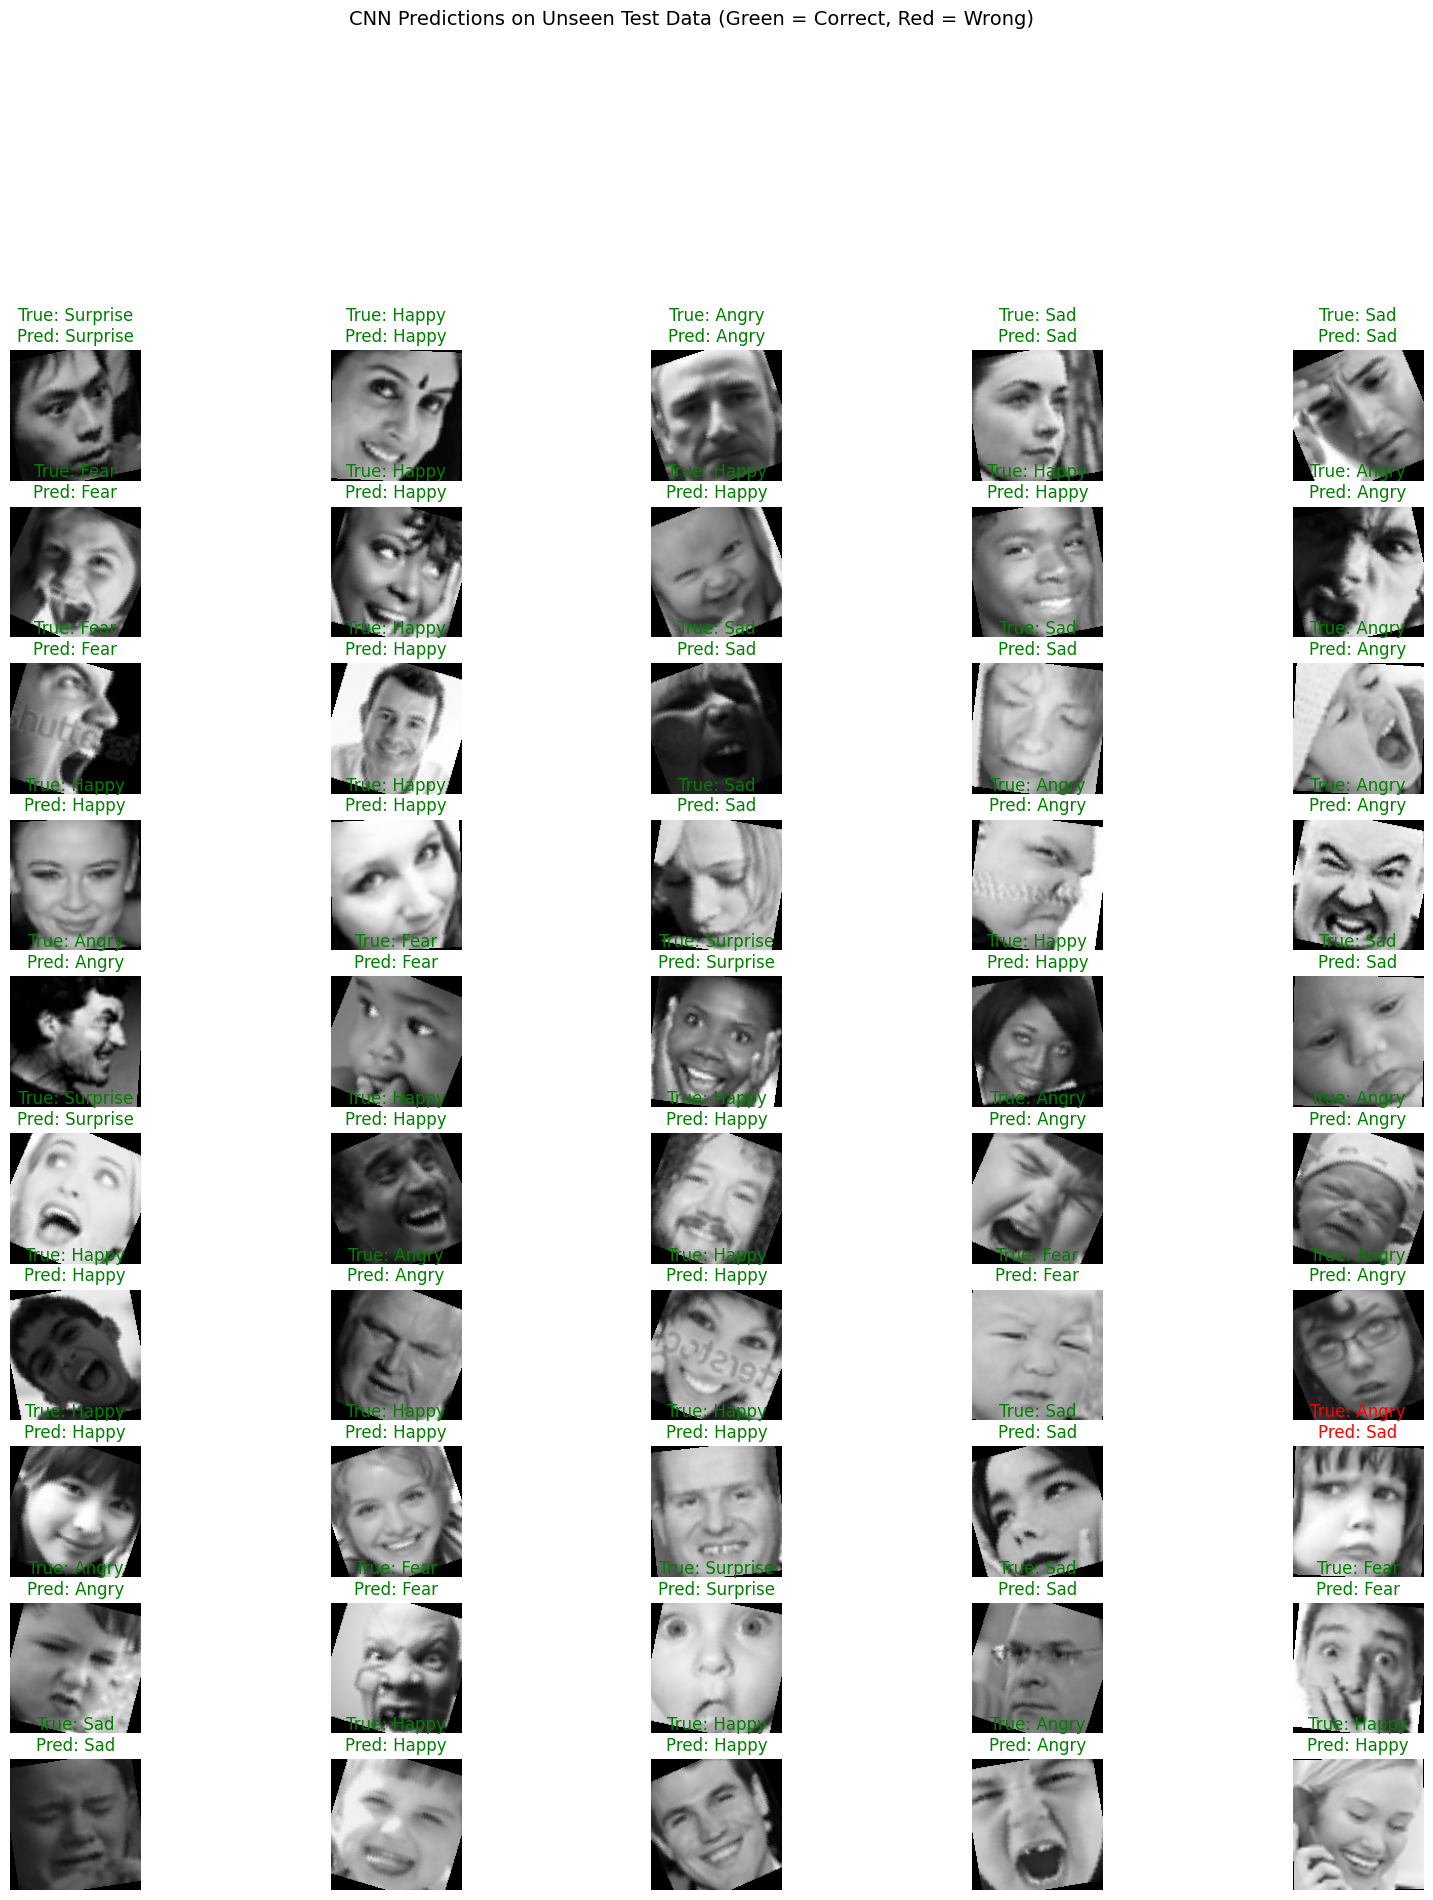

In [25]:
# Grab the first 5 samples from the raw test dataset
test_samples = []
for i in range(50):
    # Get the raw tensor and true label from the dataset
    ridx = np.random.randint(0, 64)
    x, y = next(iter(train_dataloader))
    image_tensor=x[ridx]
    true_label = y[ridx].item()
    # Get the model's prediction
    predicted_label = predict_single_image(model0, image_tensor, device)
    
    # Denormalize the image for display (if you used simple transform, 
    # it's already 0-1 and this is fine)
    image_display = image_tensor.squeeze()
    
    test_samples.append({
        'image': image_display, 
        'true': true_label, 
        'predicted': predicted_label
    })

# Plotting the results
plt.figure(figsize=(20, 20))
for i, sample in enumerate(test_samples):
    ax = plt.subplot(10, 5, i + 1)
    sample['image'] = sample['image'].permute(1, 2, 0)
    plt.imshow(sample['image'], cmap="gray")
    
    color = 'green' if sample['predicted'] == sample['true'] else 'red'
    title = f"True: {classes[sample['true']]}\nPred: {classes[sample['predicted']]}"
    
    plt.title(title, color=color)
    plt.axis("off")

plt.suptitle(
    "CNN Predictions on Unseen Test Data (Green = Correct, Red = Wrong)", 
    y=1.05, 
    fontsize=14
)
plt.show()

In [34]:
torch.save(model0, 'models/emomodel.pth')

In [8]:
model0 = torch.load('models/emomodel.pth', weights_only=False, map_location=torch.device('cuda'))